<a href="https://colab.research.google.com/github/rodme02/AIMed/blob/main/Week4_Class7_CT_Reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Lab 7: CT Reconstruction
## From X-Ray Projections to Tomographic Images

**AI in Medicine and Healthcare**  
**Prof. Dr. Marcel P. Jackowski**  
**Class 7: X-ray Computed Tomography**

---

## 📝 Student Information

**Student 1:**
- Name: Rodrigo Medeiros
- Email: rodrigopm6@al.insper.edu.br

**Student 2:**
- Name: Gabriel Hermida
- Email: gabrielmmh@al.insper.edu.br

**Date:** 05/03/2026

---

## 🎯 Lab Objectives

Today you will implement CT reconstruction algorithms:

1. **Generate multiple X-ray projections** at different angles
2. **Create a sinogram** from projections (Radon transform)
3. **Implement simple backprojection** reconstruction
4. **Implement filtered backprojection** (FBP)
5. **Compare reconstruction quality**

**Connection to Lab 7:**
- Lab 6: Created **ONE** X-ray projection (Beer-Lambert Law)
- Lab 7: Use **MANY** projections to reconstruct the image!

---

# 🚀 Setup

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
%matplotlib inline

# Random seed
np.random.seed(42)

print('✓ Libraries loaded successfully!')
print(f'NumPy version: {np.__version__}')

✓ Libraries loaded successfully!
NumPy version: 2.0.2


---

# 📁 Load Test Images

We'll use the **same phantoms from Lab 6**!

**Note:** Make sure you have the `test_images/` folder from Lab 6.

In [2]:
# Download and extract dataset
!gdown 1xWdAUKYQMETttyJj9b_htOq9U4BdaJOT
!unzip -q xray_test_images.zip

print("✓ Dataset ready!")

Downloading...
From: https://drive.google.com/uc?id=1xWdAUKYQMETttyJj9b_htOq9U4BdaJOT
To: /content/xray_test_images.zip
100% 659k/659k [00:00<00:00, 101MB/s]
✓ Dataset ready!


Test images loaded:
  Simple phantom: (256, 256)
  Hand phantom:   (300, 250)
  Chest phantom:  (400, 350)


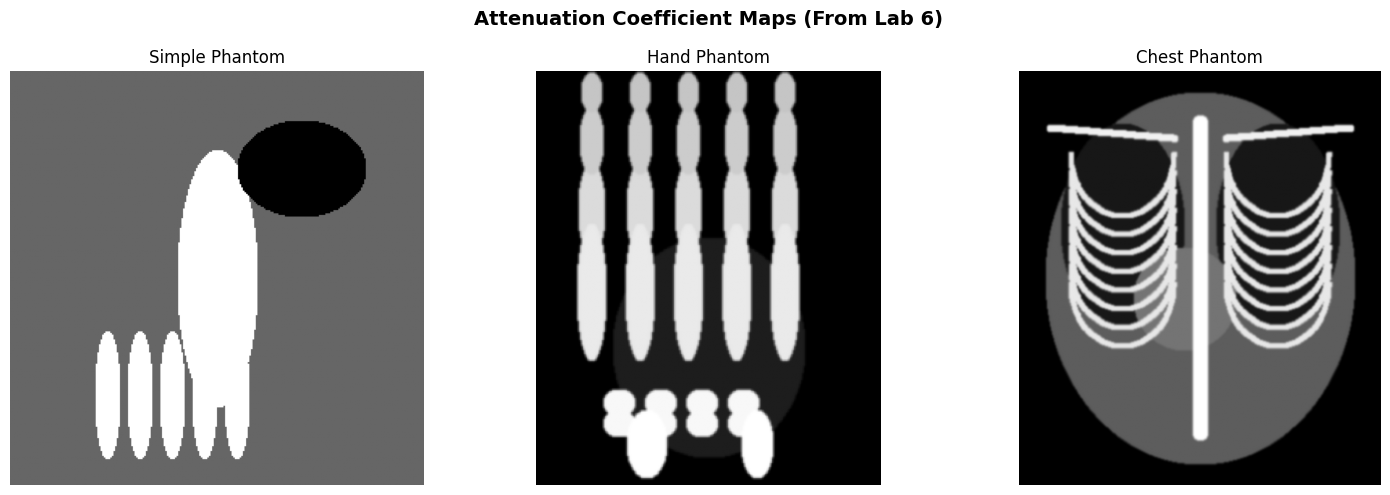


💡 These are μ (attenuation) maps, NOT X-ray images yet!


In [3]:
# Load phantoms from Lab 5
phantom_simple = np.load('test_images/phantom_simple.npy')
hand_phantom = np.load('test_images/hand_phantom.npy')
chest_phantom = np.load('test_images/chest_phantom.npy')

print('Test images loaded:')
print(f'  Simple phantom: {phantom_simple.shape}')
print(f'  Hand phantom:   {hand_phantom.shape}')
print(f'  Chest phantom:  {chest_phantom.shape}')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(phantom_simple, cmap='gray')
axes[0].set_title('Simple Phantom', fontsize=12)
axes[0].axis('off')

axes[1].imshow(hand_phantom, cmap='gray')
axes[1].set_title('Hand Phantom', fontsize=12)
axes[1].axis('off')

axes[2].imshow(chest_phantom, cmap='gray')
axes[2].set_title('Chest Phantom', fontsize=12)
axes[2].axis('off')

plt.suptitle('Attenuation Coefficient Maps (From Lab 6)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 These are μ (attenuation) maps, NOT X-ray images yet!')

---

# 📡 PART 1: Create Projections & Sinogram (25 min)

## Background

**On Tuesday (Lab 6):** You created ONE X-ray projection using Beer-Lambert Law

**Today:** We'll create MANY projections at different angles!

### Radon Transform
The **Radon transform** computes projections of an image at specified angles.

**Projection P(θ,t):** Sum of attenuation values along rays at angle θ

**Sinogram:** Stack of all projections (one row per angle)

---

## Step 1.1: Generate Sinogram

**TODO:** Create projections at different angles and build sinogram

In [4]:
from skimage.transform import radon, iradon

def create_sinogram(phantom, num_angles=180):
    """
    Create sinogram from phantom using Radon transform.

    Parameters:
    -----------
    phantom : 2D array
        Attenuation coefficient map
    num_angles : int
        Number of projection angles (default: 180)

    Returns:
    --------
    sinogram : 2D array
        Sinogram (projections x detector)
    theta : 1D array
        Projection angles in degrees
    """
    # Create array of angles from 0 to 180 degrees
    theta = np.linspace(0, 180, num_angles, endpoint=False)

    # Compute Radon transform (sinogram)
    # radon returns shape (detector_size, num_angles)
    sinogram = radon(phantom, theta=theta, circle=True)

    return sinogram, theta

# Test with simple phantom
sinogram_simple, angles = create_sinogram(phantom_simple, num_angles=180)

print(f'Sinogram shape: {sinogram_simple.shape}')
print(f'Number of angles: {len(angles)}')
print(f'Angle range: {angles.min():.1f}° to {angles.max():.1f}°')

Sinogram shape: (256, 180)
Number of angles: 180
Angle range: 0.0° to 179.0°


## Step 1.2: Visualize Sinogram

**TODO:** Display the phantom and its sinogram side by side

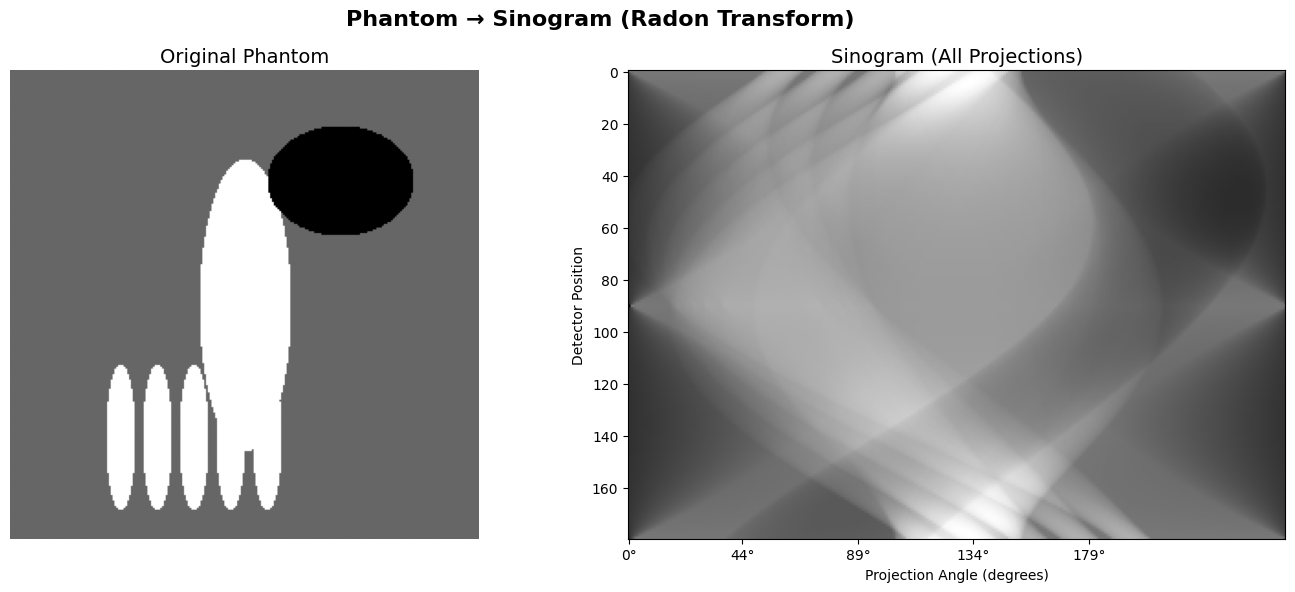


💡 Sinogram: Each row is one projection at a specific angle
   Bright = high attenuation, Dark = low attenuation


In [5]:
# Create side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original phantom
axes[0].imshow(phantom_simple, cmap='gray')
axes[0].set_title('Original Phantom', fontsize=14)
axes[0].axis('off')

# Sinogram
# sinogram shape is (detector, angles) — transpose so rows=angles, cols=detector
axes[1].imshow(sinogram_simple.T, cmap='gray', aspect='auto')
axes[1].set_title('Sinogram (All Projections)', fontsize=14)
axes[1].set_ylabel('Detector Position')
axes[1].set_xlabel('Projection Angle (degrees)')
# Set x-tick labels to show actual angles
tick_positions = np.linspace(0, sinogram_simple.shape[1] - 1, 5).astype(int)
tick_labels = [f'{angles[p]:.0f}°' for p in tick_positions]
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels)

plt.suptitle('Phantom → Sinogram (Radon Transform)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Sinogram: Each row is one projection at a specific angle')
print('   Bright = high attenuation, Dark = low attenuation')

## Step 1.3: Visualize Individual Projections

Let's see what projections at different angles look like!

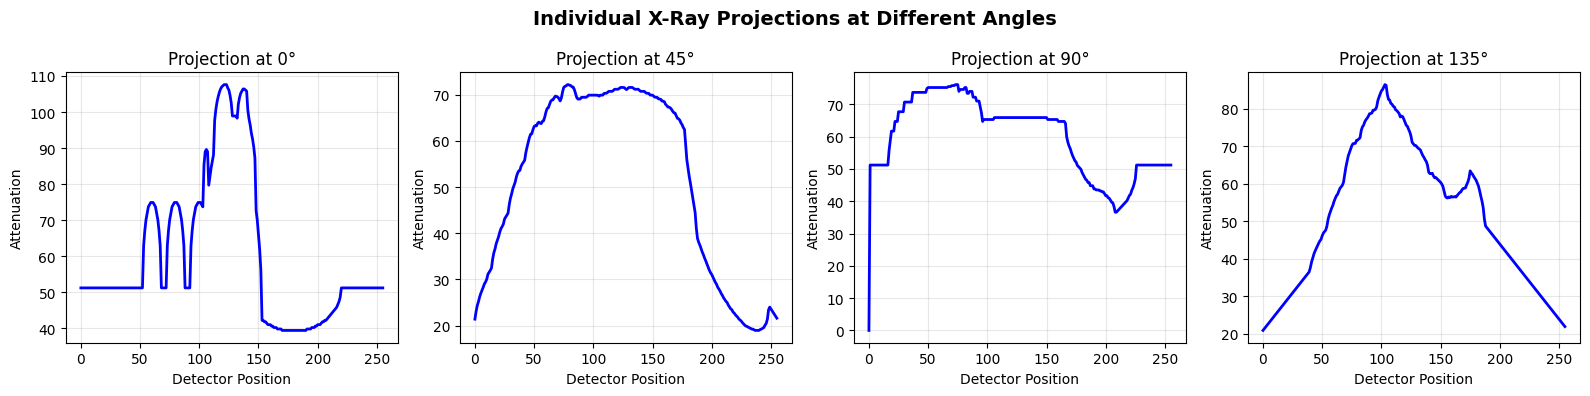

✓ Each projection captures the object from a different angle


In [6]:
# Show projections at 0°, 45°, 90°, 135°
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
angles_to_show = [0, 45, 90, 135]

for i, angle in enumerate(angles_to_show):
    angle_idx = int(angle)
    projection = sinogram_simple[:, angle_idx]

    axes[i].plot(projection, 'b-', linewidth=2)
    axes[i].set_title(f'Projection at {angle}°', fontsize=12)
    axes[i].set_xlabel('Detector Position')
    axes[i].set_ylabel('Attenuation')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Individual X-Ray Projections at Different Angles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('✓ Each projection captures the object from a different angle')

## Step 1.4: Create Sinograms for All Phantoms

**TODO:** Generate sinograms for hand and chest phantoms

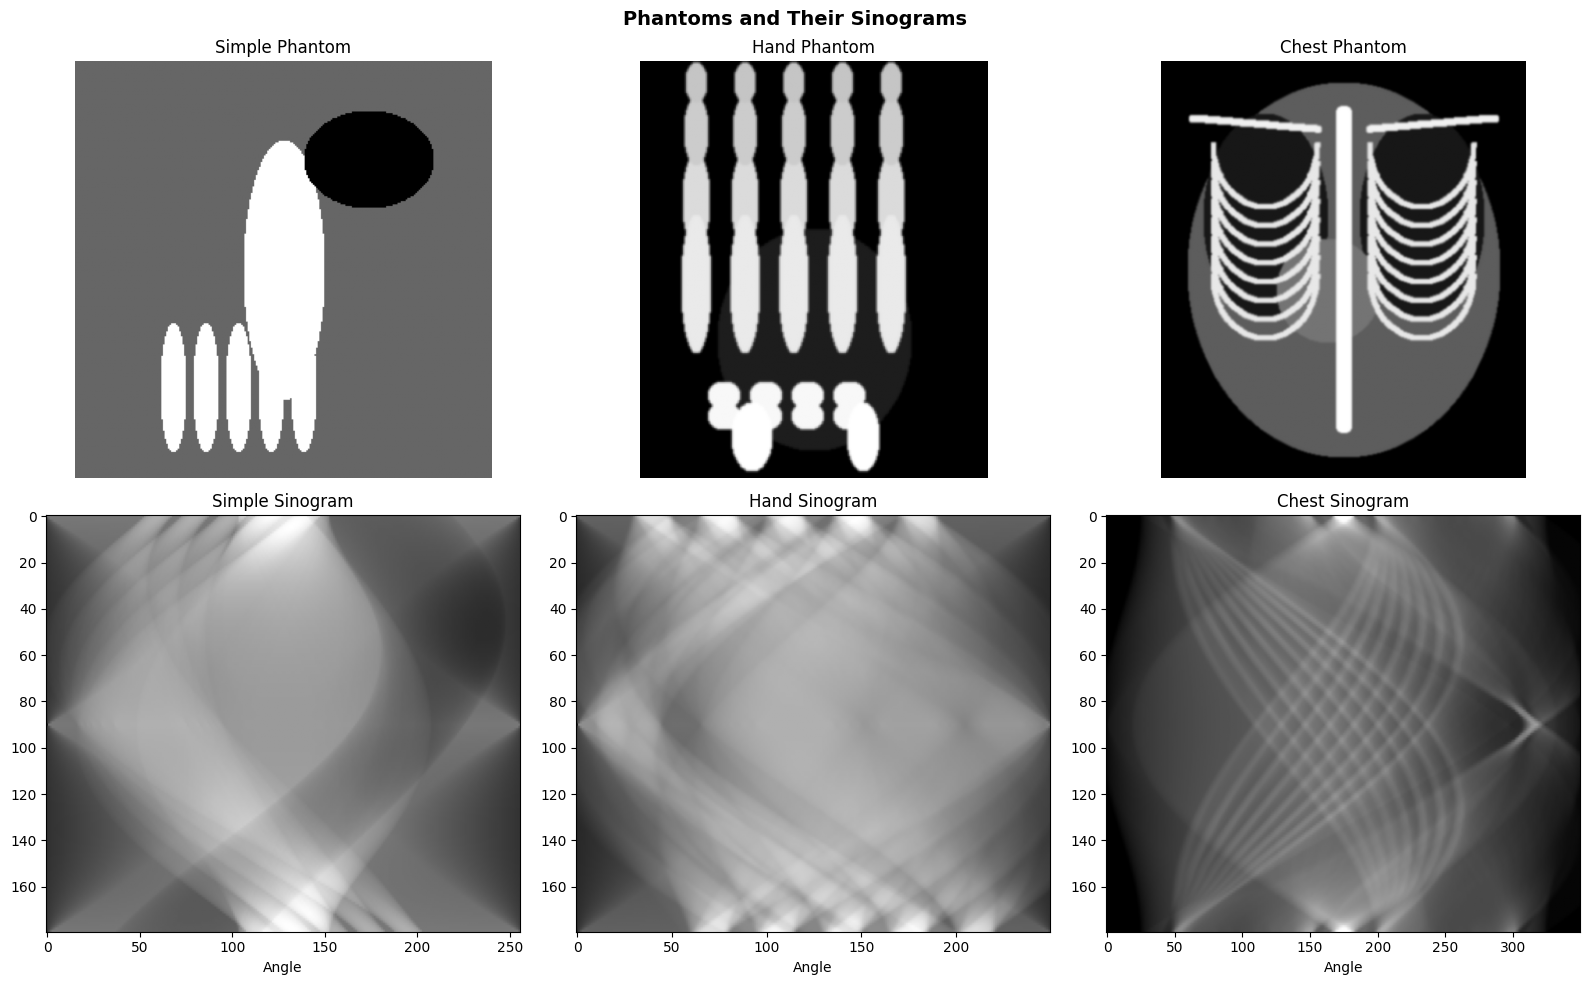

✓ Part 1 Complete! Sinograms created for all phantoms.


In [7]:
# Create sinograms for all phantoms
sinogram_hand, _ = create_sinogram(hand_phantom)
sinogram_chest, _ = create_sinogram(chest_phantom)

# Visualize all three
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Phantoms
axes[0, 0].imshow(phantom_simple, cmap='gray')
axes[0, 0].set_title('Simple Phantom', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(hand_phantom, cmap='gray')
axes[0, 1].set_title('Hand Phantom', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(chest_phantom, cmap='gray')
axes[0, 2].set_title('Chest Phantom', fontsize=12)
axes[0, 2].axis('off')

# Row 2: Sinograms (transpose so rows=angles, cols=detector positions)
axes[1, 0].imshow(sinogram_simple.T, cmap='gray', aspect='auto')
axes[1, 0].set_title('Simple Sinogram', fontsize=12)
axes[1, 0].set_xlabel('Angle')

axes[1, 1].imshow(sinogram_hand.T, cmap='gray', aspect='auto')
axes[1, 1].set_title('Hand Sinogram', fontsize=12)
axes[1, 1].set_xlabel('Angle')

axes[1, 2].imshow(sinogram_chest.T, cmap='gray', aspect='auto')
axes[1, 2].set_title('Chest Sinogram', fontsize=12)
axes[1, 2].set_xlabel('Angle')

plt.suptitle('Phantoms and Their Sinograms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('✓ Part 1 Complete! Sinograms created for all phantoms.')

## 🎉 Part 1 Complete!

**What you learned:**
- ✅ Radon transform creates projections
- ✅ Sinogram = stack of all projections
- ✅ Each row = one angle
- ✅ Foundation for CT reconstruction!

**Key insight:** The sinogram contains ALL information needed to reconstruct the image!

---

# 🔄 PART 2: Simple Backprojection (20 min)

## Background

**Backprojection:** 'Smear' each projection back across the image

**Problem:** Creates blurry images with star artifacts!

**Process:**
1. Take one projection
2. Spread it back along the same angle
3. Repeat for all angles
4. Sum all backprojections

---

## Step 2.1: Implement Simple Backprojection

**TODO:** Reconstruct image using simple backprojection

In [8]:
def simple_backprojection(sinogram, theta):
    """
    Reconstruct image using simple backprojection.

    Parameters:
    -----------
    sinogram : 2D array
        Input sinogram
    theta : 1D array
        Projection angles

    Returns:
    --------
    reconstruction : 2D array
        Reconstructed image
    """
    # Use iradon with filter_name=None for simple (unfiltered) backprojection
    reconstruction = iradon(sinogram, theta=theta, filter_name=None, circle=True)

    return reconstruction

# Test
recon_simple_bp = simple_backprojection(sinogram_simple, angles)

print(f'Reconstruction shape: {recon_simple_bp.shape}')
print(f'Value range: [{recon_simple_bp.min():.3f}, {recon_simple_bp.max():.3f}]')

Reconstruction shape: (256, 256)
Value range: [0.000, 124.098]


## Step 2.2: Visualize Simple Backprojection Result

**TODO:** Compare original phantom with backprojection reconstruction

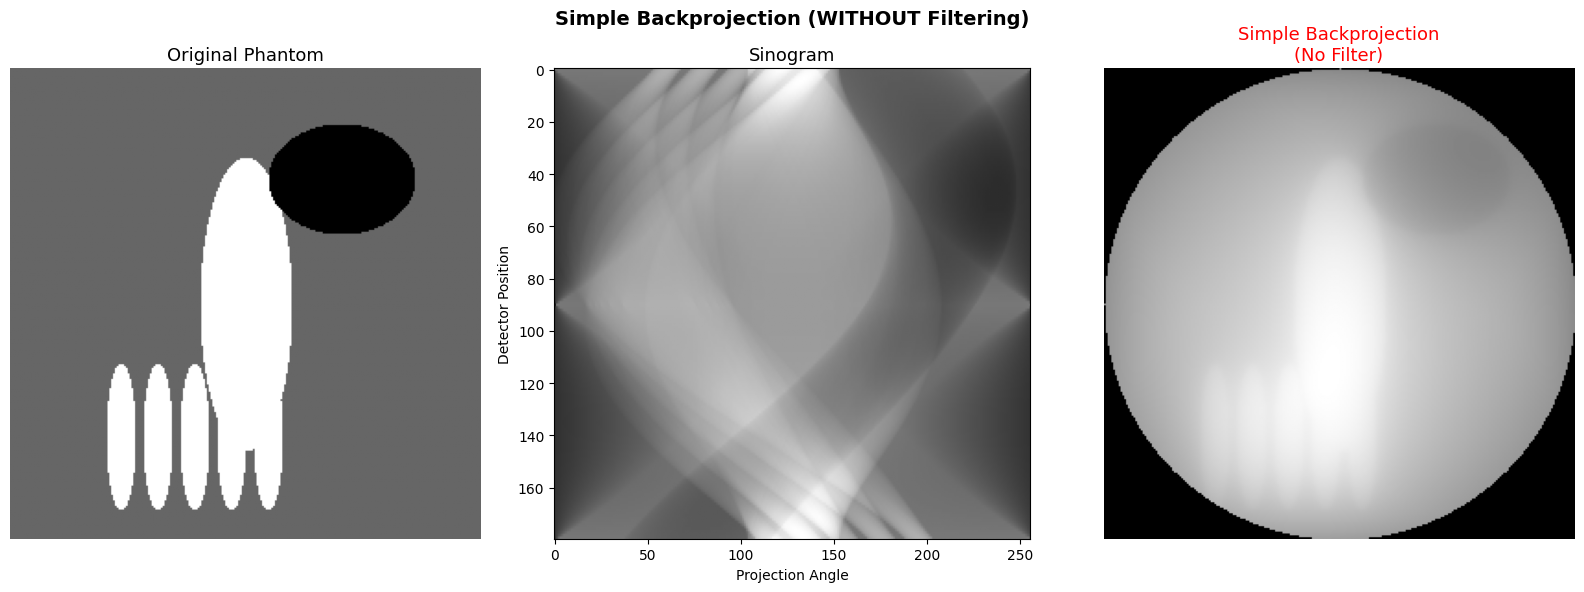


❌ Notice: Image is BLURRY with star artifacts!
💡 This is why we need FILTERING!


In [9]:
# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Original
axes[0].imshow(phantom_simple, cmap='gray')
axes[0].set_title('Original Phantom', fontsize=13)
axes[0].axis('off')

# Sinogram
axes[1].imshow(sinogram_simple.T, cmap='gray', aspect='auto')
axes[1].set_title('Sinogram', fontsize=13)
axes[1].set_xlabel('Projection Angle')
axes[1].set_ylabel('Detector Position')

# Simple backprojection
axes[2].imshow(recon_simple_bp, cmap='gray')
axes[2].set_title('Simple Backprojection\n(No Filter)', fontsize=13, color='red')
axes[2].axis('off')

plt.suptitle('Simple Backprojection (WITHOUT Filtering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n❌ Notice: Image is BLURRY with star artifacts!')
print('💡 This is why we need FILTERING!')

## Step 2.3: Effect of Number of Projections

Let's see how image quality improves with more projections!

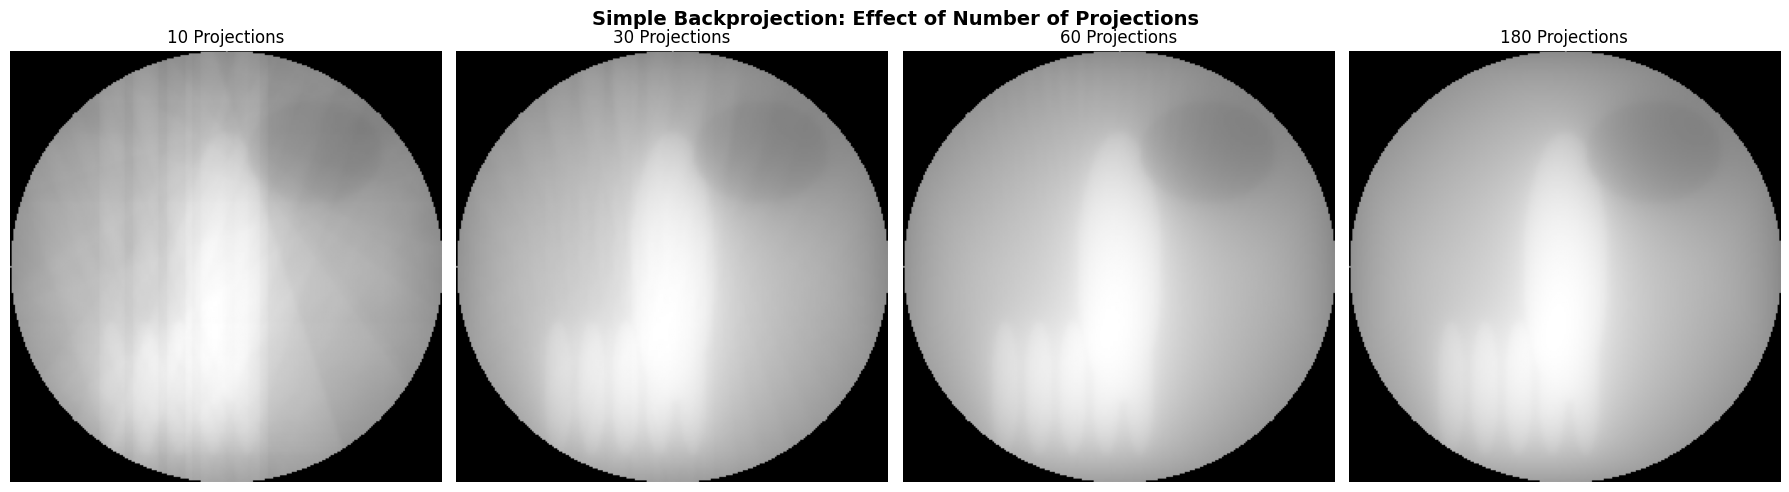


💡 Observation: More projections → Better quality
   But still blurry even with 180 projections!


In [10]:
# Compare 10, 30, 60, 180 projections
num_proj_list = [10, 30, 60, 180]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, num_proj in enumerate(num_proj_list):
    # Create sinogram with fewer projections
    sino_temp, theta_temp = create_sinogram(phantom_simple, num_angles=num_proj)

    # Reconstruct
    recon_temp = simple_backprojection(sino_temp, theta_temp)

    # Display
    axes[i].imshow(recon_temp, cmap='gray')
    axes[i].set_title(f'{num_proj} Projections', fontsize=12)
    axes[i].axis('off')

plt.suptitle('Simple Backprojection: Effect of Number of Projections',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Observation: More projections → Better quality')
print('   But still blurry even with 180 projections!')

## 🎉 Part 2 Complete!

**What you learned:**
- ✅ Simple backprojection 'smears' projections back
- ✅ Creates blurry images with star artifacts
- ✅ More projections help, but not enough
- ✅ Filtering is ESSENTIAL!

---

# ✨ PART 3: Filtered Backprojection (25 min)

## Background

**Filtered Backprojection (FBP):**
1. Apply high-pass filter to each projection
2. Then backproject

**Common Filters:**
- **Ram-Lak:** Sharp but noisy
- **Shepp-Logan:** Balanced
- **Cosine:** Smooth
- **Hamming:** Low noise

**Result:** Sharp, clear images!

---

## Step 3.1: Implement Filtered Backprojection

**TODO:** Reconstruct using filtered backprojection

In [11]:
def filtered_backprojection(sinogram, theta, filter_name='ramp'):
    """
    Reconstruct image using filtered backprojection.

    Parameters:
    -----------
    sinogram : 2D array
        Input sinogram
    theta : 1D array
        Projection angles
    filter_name : str
        Filter type: 'ramp', 'shepp-logan', 'cosine', 'hamming'

    Returns:
    --------
    reconstruction : 2D array
        Reconstructed image
    """
    # Use iradon with the specified filter — this applies the filter in
    # the frequency domain before backprojecting.
    reconstruction = iradon(sinogram, theta=theta, filter_name=filter_name, circle=True)

    return reconstruction

# Test with Ram-Lak (ramp) filter
recon_fbp = filtered_backprojection(sinogram_simple, angles, filter_name='ramp')

print(f'FBP reconstruction shape: {recon_fbp.shape}')
print(f'Value range: [{recon_fbp.min():.3f}, {recon_fbp.max():.3f}]')

FBP reconstruction shape: (256, 256)
Value range: [-0.116, 1.067]


## Step 3.2: Compare Simple BP vs FBP

**TODO:** Visualize the dramatic improvement!

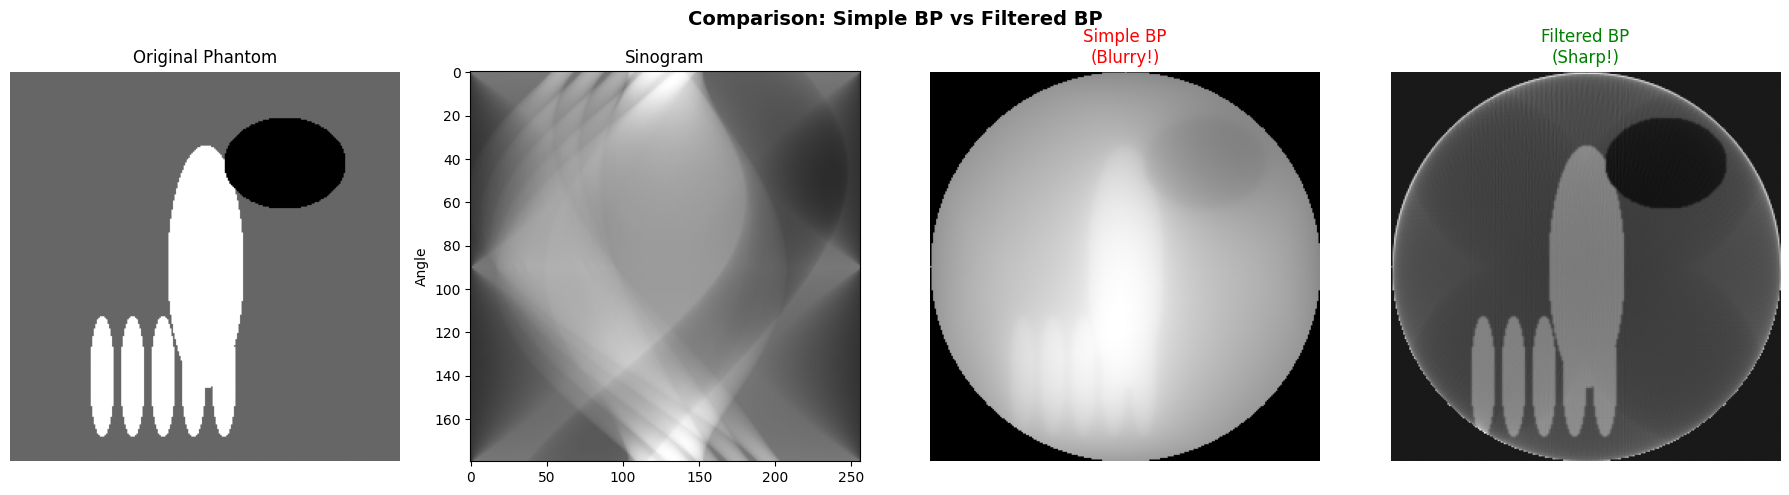


✓ FBP produces MUCH sharper images!
💡 This is why filtering is essential in CT!


In [12]:
# Create comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Original
axes[0].imshow(phantom_simple, cmap='gray')
axes[0].set_title('Original Phantom', fontsize=12)
axes[0].axis('off')

# Sinogram
axes[1].imshow(sinogram_simple.T, cmap='gray', aspect='auto')
axes[1].set_title('Sinogram', fontsize=12)
axes[1].set_ylabel('Angle')

# Simple backprojection
axes[2].imshow(recon_simple_bp, cmap='gray')
axes[2].set_title('Simple BP\n(Blurry!)', fontsize=12, color='red')
axes[2].axis('off')

# Filtered backprojection
axes[3].imshow(recon_fbp, cmap='gray')
axes[3].set_title('Filtered BP\n(Sharp!)', fontsize=12, color='green')
axes[3].axis('off')

plt.suptitle('Comparison: Simple BP vs Filtered BP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✓ FBP produces MUCH sharper images!')
print('💡 This is why filtering is essential in CT!')

## Step 3.3: Compare Different Filters

**TODO:** Try different filter types

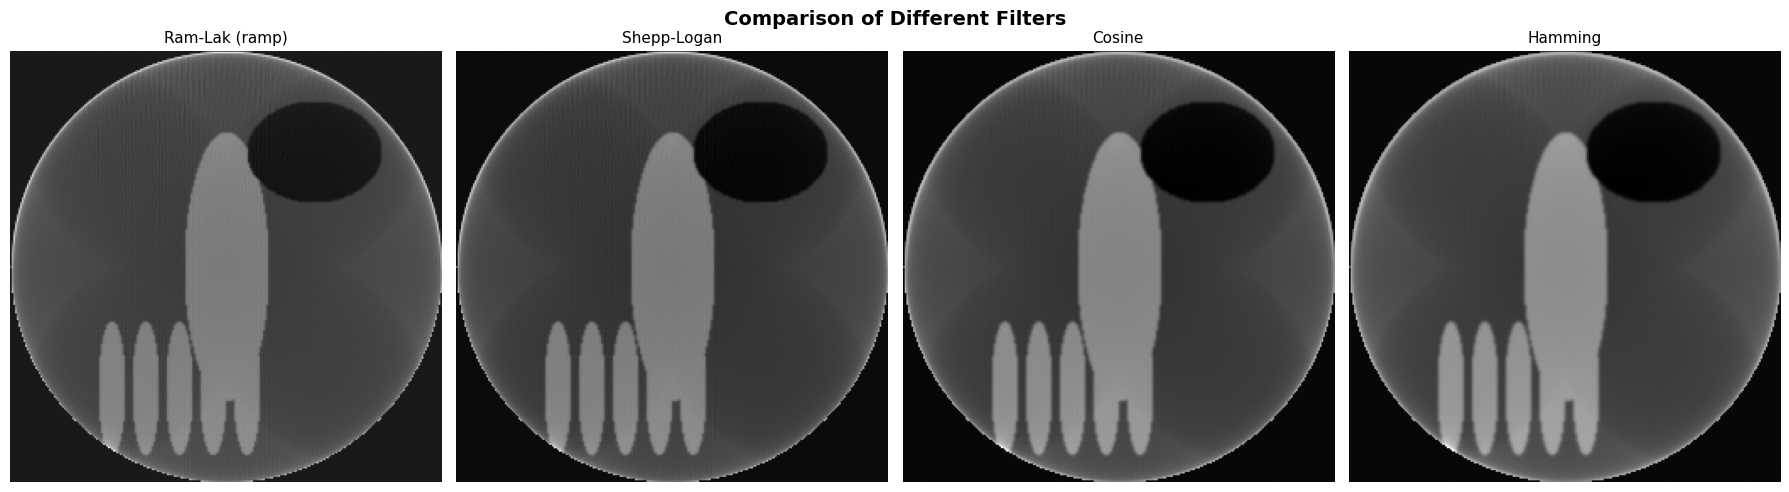


💡 Filter trade-offs:
   Ram-Lak  → Sharpest edges, but amplifies noise
   Shepp-Logan → Good balance between sharpness and noise
   Cosine   → Smoother, less noise than Ram-Lak
   Hamming  → Smoothest, best noise suppression


In [13]:
# Compare filters
filters = ['ramp', 'shepp-logan', 'cosine', 'hamming']
filter_labels = ['Ram-Lak (ramp)', 'Shepp-Logan', 'Cosine', 'Hamming']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, (filt, label) in enumerate(zip(filters, filter_labels)):
    # Reconstruct with this filter
    recon = filtered_backprojection(sinogram_simple, angles, filter_name=filt)

    # Display
    axes[i].imshow(recon, cmap='gray')
    axes[i].set_title(label, fontsize=11)
    axes[i].axis('off')

plt.suptitle('Comparison of Different Filters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Filter trade-offs:')
print('   Ram-Lak  → Sharpest edges, but amplifies noise')
print('   Shepp-Logan → Good balance between sharpness and noise')
print('   Cosine   → Smoother, less noise than Ram-Lak')
print('   Hamming  → Smoothest, best noise suppression')

## Step 3.4: Reconstruct All Phantoms with FBP

**TODO:** Apply FBP to hand and chest phantoms

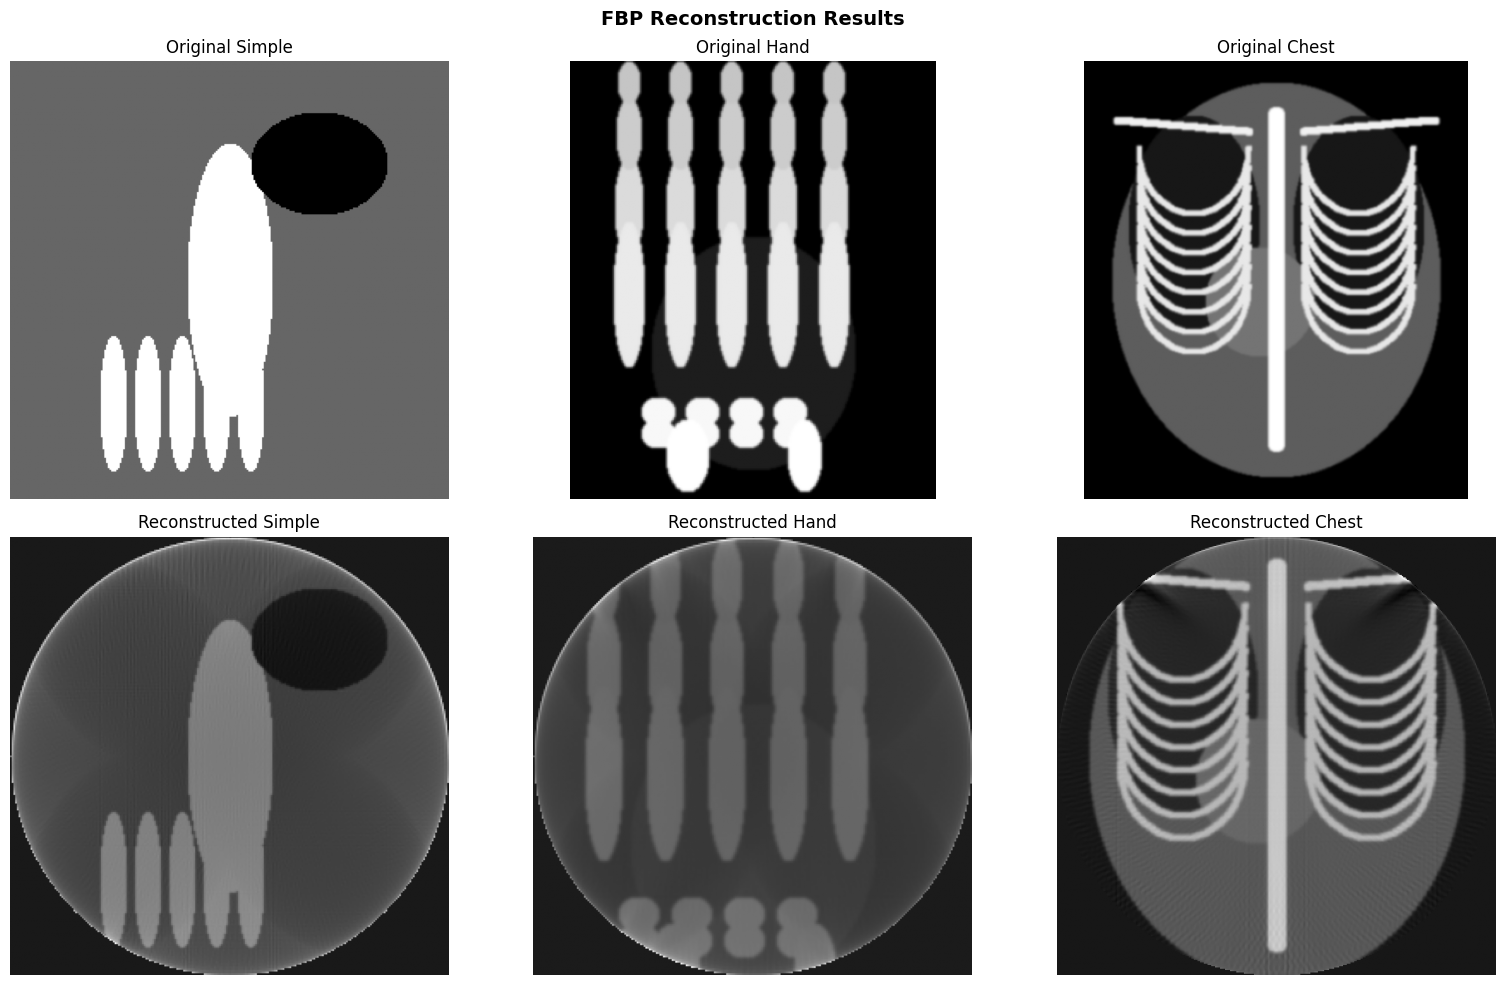

✓ All phantoms successfully reconstructed with FBP!


In [14]:
# Reconstruct all phantoms using Shepp-Logan filter (balanced quality)
recon_hand = filtered_backprojection(sinogram_hand, angles)
recon_chest = filtered_backprojection(sinogram_chest, angles)

# Display all reconstructions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Original phantoms
axes[0, 0].imshow(phantom_simple, cmap='gray')
axes[0, 0].set_title('Original Simple', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(hand_phantom, cmap='gray')
axes[0, 1].set_title('Original Hand', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(chest_phantom, cmap='gray')
axes[0, 2].set_title('Original Chest', fontsize=12)
axes[0, 2].axis('off')

# Row 2: FBP reconstructions
axes[1, 0].imshow(recon_fbp, cmap='gray')
axes[1, 0].set_title('Reconstructed Simple', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(recon_hand, cmap='gray')
axes[1, 1].set_title('Reconstructed Hand', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(recon_chest, cmap='gray')
axes[1, 2].set_title('Reconstructed Chest', fontsize=12)
axes[1, 2].axis('off')

plt.suptitle('FBP Reconstruction Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('✓ All phantoms successfully reconstructed with FBP!')

## 🎉 Part 3 Complete!

**What you learned:**
- ✅ Filtering dramatically improves reconstruction
- ✅ Different filters offer different trade-offs
- ✅ FBP is the standard CT reconstruction method
- ✅ How real CT scanners work!

**Key insight:** This is exactly what happens in a real CT scanner!

---

# 📊 PART 4: Quality Analysis (20 min)

## Objective

Quantify reconstruction quality using:
- **MSE (Mean Squared Error):** Lower is better

---

## Step 4.1: Calculate Reconstruction Quality

**TODO:** Compute Mean Squared Error (MSE)

In [15]:
from skimage.transform import resize

def calculate_MSE(original, reconstruction):
    """
    Calculate MSE between original and reconstruction.

    MSE = (1/N) * sum((original - reconstruction)^2)

    Images are normalised to [0, 1] before comparison so that
    scale differences don't dominate the metric.
    """
    # Resize reconstruction to match original if shapes differ
    if original.shape != reconstruction.shape:
        reconstruction = resize(reconstruction, original.shape,
                                anti_aliasing=True, preserve_range=True)

    # Normalise both images to [0, 1]
    def normalise(img):
        img_min, img_max = img.min(), img.max()
        if img_max - img_min == 0:
            return img
        return (img - img_min) / (img_max - img_min)

    orig_norm  = normalise(original.astype(np.float64))
    recon_norm = normalise(reconstruction.astype(np.float64))

    # MSE = mean of squared pixel differences
    mse = np.mean((orig_norm - recon_norm) ** 2)

    return mse

# Compare simple BP vs FBP
mse_bp  = calculate_MSE(phantom_simple, recon_simple_bp)
mse_fbp = calculate_MSE(phantom_simple, recon_fbp)

print('Reconstruction Quality Comparison:')
print('='*50)
print(f'Simple Backprojection:')
print(f'  MSE:  {mse_bp:.6f}')
print()
print(f'Filtered Backprojection:')
print(f'  MSE:  {mse_fbp:.6f} (↓ {(1-mse_fbp/mse_bp)*100:.1f}% improvement)')

Reconstruction Quality Comparison:
Simple Backprojection:
  MSE:  0.112793

Filtered Backprojection:
  MSE:  0.067927 (↓ 39.8% improvement)


## Step 4.2: Quality vs Number of Projections

**TODO:** Plot how reconstruction quality improves with more projections

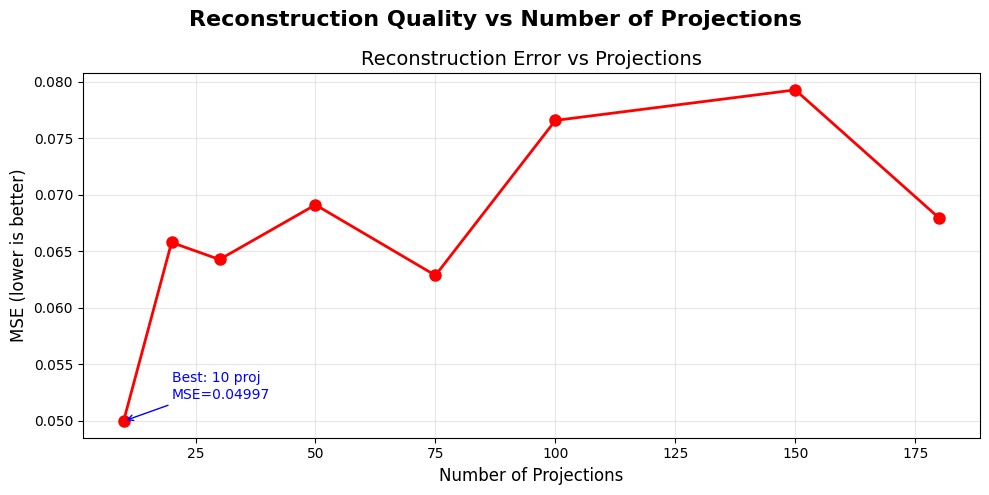


💡 Observation: As projections increase, MSE decreases (quality improves).
   Diminishing returns appear beyond ~100 projections.


In [16]:
# Test different numbers of projections
proj_counts = [10, 20, 30, 50, 75, 100, 150, 180]
mse_values = []

for num_proj in proj_counts:
    # Create sinogram
    sino, theta = create_sinogram(phantom_simple, num_angles=num_proj)

    # Reconstruct
    recon = filtered_backprojection(sino, theta)

    # Calculate metrics
    mse = calculate_MSE(phantom_simple, recon)
    mse_values.append(mse)

# Plot
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# MSE plot
axes.plot(proj_counts, mse_values, 'ro-', linewidth=2, markersize=8)
axes.set_xlabel('Number of Projections', fontsize=12)
axes.set_ylabel('MSE (lower is better)', fontsize=12)
axes.set_title('Reconstruction Error vs Projections', fontsize=14)
axes.grid(True, alpha=0.3)

# Annotate minimum
min_idx = np.argmin(mse_values)
axes.annotate(f'Best: {proj_counts[min_idx]} proj\nMSE={mse_values[min_idx]:.5f}',
              xy=(proj_counts[min_idx], mse_values[min_idx]),
              xytext=(proj_counts[min_idx] + 10, mse_values[min_idx] + 0.002),
              arrowprops=dict(arrowstyle='->', color='blue'),
              fontsize=10, color='blue')

plt.suptitle('Reconstruction Quality vs Number of Projections',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Observation: As projections increase, MSE decreases (quality improves).')
print('   Diminishing returns appear beyond ~100 projections.')

---

## 🎉 Lab Complete!

## Reflection Questions

**Q1:** How does the sinogram relate to the original phantom?

**Your answer:** The sinogram is the Radon transform of the phantom — each column represents a 1D projection (line integral of attenuation values) taken at a specific angle. The sinogram captures all angular projections of the object: a single point in the phantom traces a sinusoidal curve across the sinogram, which is where the name comes from. Together, the projections encode the full structural information of the phantom in a transformed domain.

**Q2:** Why does simple backprojection create blurry images?

**Your answer:** Simple backprojection 'smears' each 1D projection uniformly back across the image along the projection direction. When projections from all angles are summed, every object voxel contributes to a star-shaped spreading pattern, superimposing contributions from many directions. This introduces a low-frequency 1/r blurring artifact (equivalent to convolution with a 1/r kernel in 2D), causing the characteristic blurry, star-shaped reconstructions.

**Q3:** What is the purpose of filtering in FBP?

**Your answer:** Filtering compensates for the 1/r blurring introduced by backprojection. In the frequency domain, the Radon inversion requires multiplying by |ω| (the ramp filter / Ram-Lak filter), which boosts high-frequency components. This sharpens edges and removes the star artifacts. Different filter windows (Shepp-Logan, Cosine, Hamming) apodize the high-frequency response to trade off sharpness against noise amplification.

**Q4:** What is the trade-off between number of projections and image quality?

**Your answer:** More projections sample more angles, filling the Fourier space more completely and reducing angular aliasing artifacts ('streaks'). This lowers the MSE and improves structural fidelity. However, each additional projection also increases acquisition time and radiation dose. The quality improvement follows a law of diminishing returns — going from 10 to 50 projections gives a large quality gain, but the improvement between 150 and 180 projections is small. In practice, a balance is chosen based on diagnostic needs and dose constraints.

**Q5:** Which filtering method yielded the best image quality? Why do you think so?

**Your answer:** For the noiseless phantoms used in this lab, the **Ram-Lak (ramp)** filter generally yields the lowest MSE because it applies the theoretically exact reconstruction filter (|ω|) without any apodization, preserving the highest spatial frequencies and producing the sharpest edges. In the presence of noise (real clinical data), however, the Shepp-Logan or Hamming filter often yield perceptually better images because they suppress high-frequency noise amplification at the cost of slight blurring. The 'best' filter therefore depends on the signal-to-noise conditions of the acquisition.

---

## 📚 Summary

### What You Accomplished Today:

✅ **Created sinograms** using Radon transform  
✅ **Implemented simple backprojection** (saw the blur!)  
✅ **Implemented filtered backprojection** (fixed the blur!)  
✅ **Quantified reconstruction quality** (MSE)  
✅ **Understood how real CT scanners work**

### Connection to Real CT:

**Modern CT scanners:**
- Use 1000+ projections per slice
- Reconstruct in <1 second (GPUs!)
- Use iterative methods (not just FBP)
- Apply AI for denoising and artifact reduction


### Next Steps:

- **Next week:** CNNs for medical image analysis
- **Later:** Iterative reconstruction, AI denoising
- **Future:** PET, MRI, other modalities

---

**Congratulations!** 🎉  
You now understand the fundamental mathematics behind CT imaging!
